## 해빙면적 / 해빙 실면적 (1979 ~ 2025)

### 해빙면적 / 해빙 실면적 월별 (1979 ~ 2025)

In [4]:
import pandas as pd
import glob

# 현재 경로에 있는 N_01_extent_v3.0.csv ~ N_12_extent_v3.0.csv 자동 탐색
file_paths = sorted(glob.glob("./data/test/N_??_extent_v3.0.csv"))  # 예: N_01_extent_v3.0.csv

# 데이터를 저장할 리스트
monthly_data = []

# 월별 파일 하나씩 읽기
for path in file_paths:
    month = int(path.split("_")[1])  # 파일명에서 월 번호 추출 (01~12)

    # 고정폭 텍스트 파일로 읽기
    df = pd.read_fwf(path, skiprows=2, header=None,
                     names=["year", "month_raw", "data_type", "region", "extent", "area"])

    df["mo"] = month  # 명시적으로 월 정보 지정
    df = df[["year", "mo", "extent", "area"]]  # 필요한 컬럼만 선택

    monthly_data.append(df)

# 전체 데이터 병합
df_all = pd.concat(monthly_data, ignore_index=True)

# 날짜 컬럼 생성 및 정렬
df_all["date"] = pd.to_datetime(df_all["year"].astype(str) + "-" + df_all["mo"].astype(str).str.zfill(2))
df_all = df_all.sort_values("date").set_index("date")

# 쉼표 제거 후 숫자형으로 변환
df_all["extent"] = df_all["extent"].astype(str).str.replace(",", "").str.strip().astype(float)
df_all["area"] = df_all["area"].astype(str).str.replace(",", "").str.strip().astype(float)

# CSV로 저장
df_all.to_csv("seaice_extent_all_months.csv", index=True)

# 확인용 출력
print("CSV 저장 완료: N_seaice_extent_all_months.csv")
print(df_all.head())

CSV 저장 완료: N_seaice_extent_all_months.csv
             year  mo  extent   area
date                                
1979-11-01  1979,  11   10.94   8.37
1979-12-01  1979,  12   13.34  10.63
1980-01-01  1980,   1   14.86  11.94
1980-02-01  1980,   2   15.96  12.90
1980-03-01  1980,   3   16.04  12.99


C:\Users\user\AppData\Local\Temp\ipykernel_24932\1910633078.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_all["date"] = pd.to_datetime(df_all["year"].astype(str) + "-" + df_all["mo"].astype(str).str.zfill(2))


### 해빙면적 / 해빙 실면적 일별 (1979 ~ 2025)

In [6]:
import pandas as pd

# 원본 CSV 파일 경로
file_path = "./data/test/N_seaice_extent_daily_v3.0.csv"

# 2행까지 건너뛰고 불러오기
df = pd.read_csv(file_path, skiprows=2)

# 컬럼 이름 지정
df.columns = ["year", "month", "day", "extent", "missing", "source_data"]

# 날짜 컬럼 만들기
df["date"] = pd.to_datetime(df[["year", "month", "day"]])

# 날짜 기준 정렬 및 인덱스 설정
df = df.sort_values("date").set_index("date")

# 분석에 필요 없는 컬럼 제거 (선택)
df_cleaned = df[["year", "month", "day", "extent", "area"]] if "area" in df.columns else df[["year", "month", "day", "extent"]]

# 새로 저장
df_cleaned.to_csv("N_seaice_extent_daily_cleaned.csv", index=True)

print("저장 완료: N_seaice_extent_daily_cleaned.csv")

저장 완료: N_seaice_extent_daily_cleaned.csv


## AO, NAO, PDO

### 각 파일 년월 -> 날짜로 저장

In [ ]:
import pandas as pd

# 파일 불러오기
df = pd.read_csv("ao.data.txt", delim_whitespace=True, skiprows=1, header=None)

# 1. 연도 있는 행만 남기기 (ex. '1950', '1981', ...)
df = df[df[0].astype(str).str.match(r"\d{4}")]

# 2. 컬럼 이름 지정
df.columns = ["year"] + list(range(1, 13))  # 1~12 = JAN~DEC

# 3. wide → long 변환 (연도 + 월 → 긴 형태)
df = df.melt(id_vars=["year"], var_name="month", value_name="value")

# 4. 연도 + 월 → 날짜 컬럼 만들기
df["date"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" + df["month"].astype(str).str.zfill(2))

# 5. 원하는 형태로 정리
df = df[["date", "value"]].dropna()

### .data 파일 -> csv저장

### 데이터 병합

In [1]:
import pandas as pd

# 1. 파일 경로 설정
extent_path = "./data/project_data/N_seaice_extent_daily_cleaned.csv"
external_path = "./data/project_data/AO_NAO_PDO_combined.csv"

# 2. 해빙 면적 데이터 불러오기
extent_df = pd.read_csv(extent_path, parse_dates=["date"], index_col="date")
extent_df = extent_df[["extent"]]  # 필요한 열만 사용

# 3. 외생 변수 (AO, NAO, PDO) 데이터 불러오기
external_df = pd.read_csv(external_path, parse_dates=["date"], index_col="date")

# 4. 외생 변수가 월별이므로 → 일별로 forward fill
external_daily = external_df.resample("D").ffill()

# 5. 병합 (공통 날짜 기준)
merged_df = extent_df.join(external_daily, how="inner")

# 6. 저장
merged_df.to_csv("./data/project_data/seaice_with_external_factors.csv", index=True)

# 7. 확인
print("병합 완료! 저장된 파일명: seaice_with_external_factors.csv")
print(merged_df.head())

병합 완료! 저장된 파일명: seaice_with_external_factors.csv
            extent     AO   NAO   PDO
date                                 
1978-10-28  10.420  0.895  2.61  0.10
1978-10-30  10.557  0.895  2.61  0.10
1978-11-01  10.670  2.470  3.06 -0.07
1978-11-03  10.777  2.470  3.06 -0.07
1978-11-05  10.968  2.470  3.06 -0.07


In [7]:
import pandas as pd

# 각 파일 경로
ao_path = "./data/project_data/ao.data.txt"
nao_path = "./data/project_data/nao.data.txt"
pdo_path = "./data/project_data/pdo.data.txt"

# 공통 처리 함수
def read_noaa_index(file_path, var_name):
    # 파일 읽기 (공백 구분)
    df = pd.read_csv(file_path, delim_whitespace=True, skiprows=1, header=None)

    # 첫 열이 연도인 행만 필터링
    df = df[df.iloc[:, 0].astype(str).str.match(r"\d{4}")]

    # 컬럼 이름 설정
    df.columns = ["year"] + list(range(1, 13))

    # 월별 데이터를 긴 형식으로 변환
    df = df.melt(id_vars=["year"], var_name="month", value_name=var_name)

    # 날짜 생성
    df["date"] = pd.to_datetime(df["year"].astype(int).astype(str) + "-" + df["month"].astype(str).str.zfill(2))

    # 필요한 컬럼만 정리
    return df[["date", var_name]].dropna().set_index("date")

# 각 지수 불러오기
ao_df = read_noaa_index(ao_path, "AO")
nao_df = read_noaa_index(nao_path, "NAO")
pdo_df = read_noaa_index(pdo_path, "PDO")

# 날짜 기준으로 병합
combined_df = ao_df.join(nao_df).join(pdo_df)

# CSV 저장
combined_df.to_csv("AO_NAO_PDO_combined.csv")

print("저장 완료: AO_NAO_PDO_combined.csv")

저장 완료: AO_NAO_PDO_combined.csv


# 해빙면적 데이터

## 파일 확인

In [30]:
# !pip install ipykernel

In [1]:
import xarray as xr

# NetCDF 파일 열기 (netCDF4 엔진 명시)
ds = xr.open_dataset("./data/icedata/SIC_beaufort_1979-2024.nc", engine="netcdf4")

# 구조 요약 출력
print(ds)

<xarray.Dataset>
Dimensions:  (time: 16618, y: 38, x: 52)
Coordinates:
  * x        (x) float64 -2.338e+06 -2.312e+06 ... -1.088e+06 -1.062e+06
  * y        (y) float64 -4.125e+05 -4.375e+05 ... -1.312e+06 -1.338e+06
  * time     (time) datetime64[ns] 1979-01-01 1979-01-02 ... 2024-06-30
Data variables:
    ICECON   (time, y, x) float32 ...
    crs      (time, y, x) |S8 ...
Attributes:
    title:                  보퍼트해 해빙 농도 보간 데이터
    created:                2025-04-21 18:43:43
    interpolation_applied:  True
    gapfill_full:           True


# 해빙면적 계산

In [4]:
import xarray as xr
import numpy as np
import pandas as pd

# 파일 열기
ds = xr.open_dataset("./data/icedata/SIC_beaufort_1979-2024.nc", engine="netcdf4")

# SIC 변수 추출
sic = ds["ICECON"]

# SIC 값이 0.15 이상인 곳을 1로 간주 (해빙 존재), 아니면 0
ice_presence = sic >= 0.15

# 각 날짜별 해빙 면적 (픽셀 수 기준 합)
daily_area = ice_presence.sum(dim=["x", "y"])

# 월별 평균 해빙 면적
monthly_area = daily_area.resample(time="1MS").mean()

# Pandas DataFrame으로 저장
df_monthly = monthly_area.to_dataframe(name="ice_area")
df_monthly.reset_index(inplace=True)

# CSV로 저장
df_monthly.to_csv("./data/icedata/monthly_ice_area.csv", index=False)

## 시각화

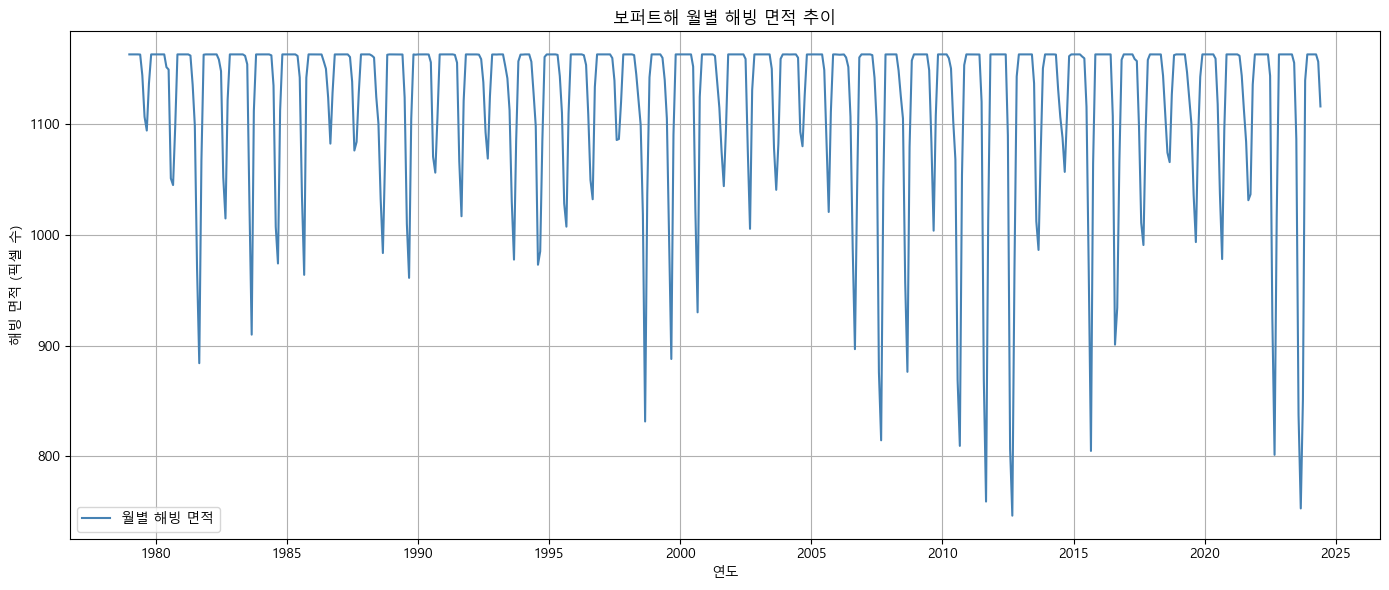

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows 환경용)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# CSV 파일 불러오기
df = pd.read_csv("./data/icedata/monthly_ice_area.csv", parse_dates=["time"])

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(df["time"], df["ice_area"], label="월별 해빙 면적", color='steelblue')
plt.title("보퍼트해 월별 해빙 면적 추이")
plt.xlabel("연도")
plt.ylabel("해빙 면적 (픽셀 수)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

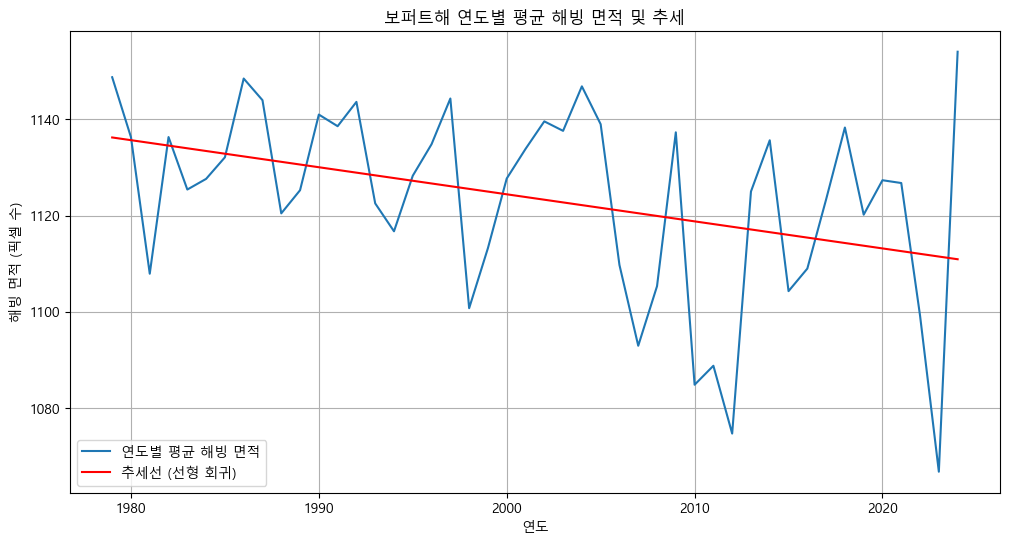

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 데이터 로드
df = pd.read_csv("./data/icedata/monthly_ice_area.csv", parse_dates=["time"])
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month

# 연도별 평균 해빙 면적 계산
df_yearly = df.groupby("year")["ice_area"].mean().reset_index()

# 선형 회귀 추세선
X = df_yearly["year"].values.reshape(-1, 1)
y = df_yearly["ice_area"].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(df_yearly["year"], df_yearly["ice_area"], label="연도별 평균 해빙 면적")
plt.plot(df_yearly["year"], y_pred, label="추세선 (선형 회귀)", color="red")
plt.title("보퍼트해 연도별 평균 해빙 면적 및 추세")
plt.xlabel("연도")
plt.ylabel("해빙 면적 (픽셀 수)")
plt.grid(True)
plt.legend()
plt.show()

## ARIMA 예측

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


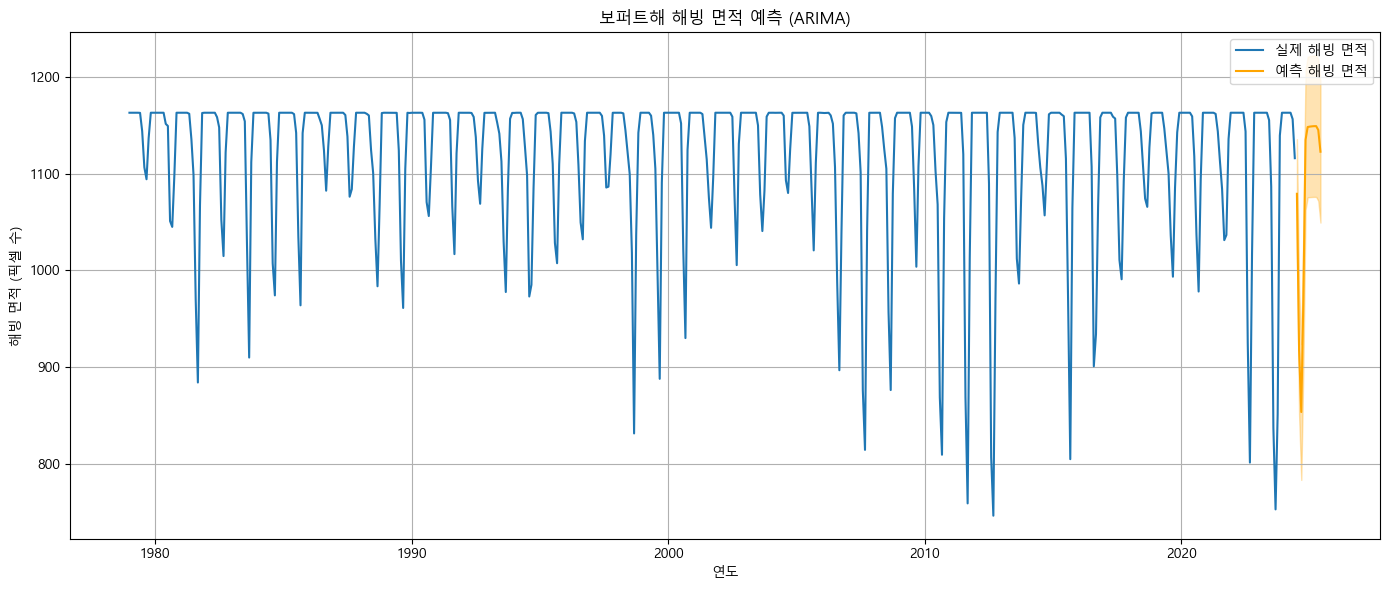

         time  predicted_ice_area
0  2024-07-01         1079.184444
1  2024-08-01          917.252894
2  2024-09-01          853.543700
3  2024-10-01          969.909939
4  2024-11-01         1135.023288
5  2024-12-01         1148.229866
6  2025-01-01         1148.666889
7  2025-02-01         1148.943065
8  2025-03-01         1149.110528
9  2025-04-01         1149.145226
10 2025-05-01         1145.182722
11 2025-06-01         1122.696524


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib as mpl

# 한글 폰트 설정 (Windows용)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv("./data/icedata/monthly_ice_area.csv", parse_dates=["time"])
df.set_index("time", inplace=True)

# ARIMA 모델 정의 및 학습
# order=(p,d,q), seasonal_order=(P,D,Q,s) → s=12는 월 단위 계절성
model = SARIMAX(df["ice_area"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit()

# 향후 12개월 예측
forecast = results.get_forecast(steps=12)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 예측 결과 시각화
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["ice_area"], label="실제 해빙 면적")
plt.plot(pred_mean.index, pred_mean, label="예측 해빙 면적", color="orange")
plt.fill_between(pred_mean.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color="orange", alpha=0.3)
plt.title("보퍼트해 해빙 면적 예측 (ARIMA)")
plt.xlabel("연도")
plt.ylabel("해빙 면적 (픽셀 수)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 예측 결과를 데이터프레임으로 출력
forecast_df = pred_mean.reset_index()
forecast_df.columns = ["time", "predicted_ice_area"]
print(forecast_df)

In [23]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 데이터 불러오기
df = pd.read_csv("./data/icedata/monthly_ice_area.csv", parse_dates=["time"])
df.set_index("time", inplace=True)

# 훈련용 / 테스트용 분리 (최근 12개월은 테스트용)
train = df.iloc[:-12]
test = df.iloc[-12:]

# ARIMA 모델 학습 (훈련용만 사용)
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train["ice_area"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results = model.fit()

# 12개월 예측
forecast = results.get_forecast(steps=12)
pred = forecast.predicted_mean
pred.index = test.index  # 인덱스 맞추기

# 성능 지표 계산
mae = mean_absolute_error(test["ice_area"], pred)
rmse = mean_squared_error(test["ice_area"], pred, squared=False)
mape = (abs((test["ice_area"] - pred) / test["ice_area"])).mean() * 100

# 출력
print(f" MAE (평균 절대 오차): {mae:.2f}")
print(f" RMSE (평균 제곱근 오차): {rmse:.2f}")
print(f" MAPE (평균 절대 백분율 오차): {mape:.2f}%")

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


 MAE (평균 절대 오차): 54.03
 RMSE (평균 제곱근 오차): 88.70
 MAPE (평균 절대 백분율 오차): 6.26%


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## LSTM 모델

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# 1. 데이터 불러오기
df = pd.read_csv("./data/icedata/monthly_ice_area.csv", parse_dates=["time"])
df.set_index("time", inplace=True)
data = df["ice_area"].values.reshape(-1, 1)

# 2. 정규화
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

# 3. 시퀀스 데이터 생성 함수
def make_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, window=12)

# 4. 학습/테스트 분리 (80% 학습)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. LSTM 모델 정의
model = Sequential([
    LSTM(64, activation='relu', input_shape=(12, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)

# 6. 예측
pred_scaled = model.predict(X_test)
pred = scaler.inverse_transform(pred_scaled)
y_true = scaler.inverse_transform(y_test)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step


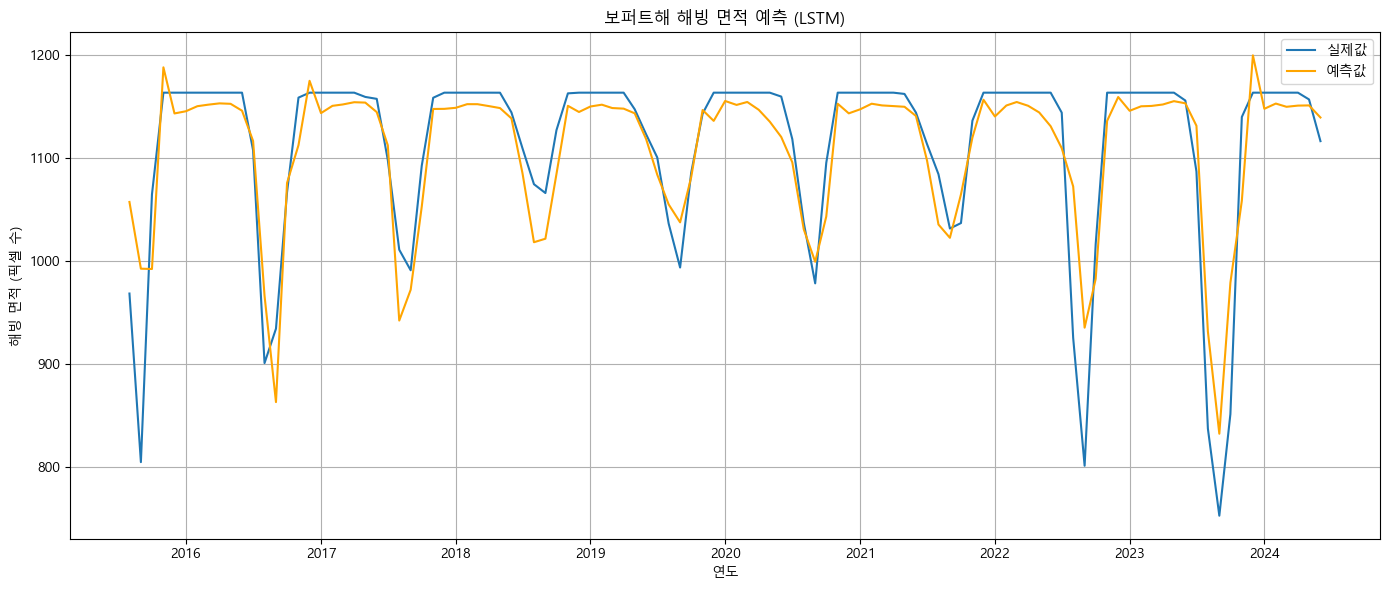

In [15]:
# 7. 시각화
dates = df.index[12+split:]
plt.figure(figsize=(14,6))
plt.plot(dates, y_true, label="실제값")
plt.plot(dates, pred, label="예측값", color="orange")
plt.title("보퍼트해 해빙 면적 예측 (LSTM)")
plt.xlabel("연도")
plt.ylabel("해빙 면적 (픽셀 수)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 예측 vs 실제: y_true, pred 는 이미 있는 상태
mae = mean_absolute_error(y_true, pred)
rmse = mean_squared_error(y_true, pred, squared=False)
mape = np.mean(np.abs((y_true - pred) / y_true)) * 100

print(f" LSTM MAE: {mae:.2f}")
print(f" LSTM RMSE: {rmse:.2f}")
print(f" LSTM MAPE: {mape:.2f}%")

 LSTM MAE: 27.21
 LSTM RMSE: 41.41
 LSTM MAPE: 2.69%


C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## + 슬라이딩 윈도우

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib as mpl

# 한글 폰트 설정
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 1. 데이터 불러오기
df = pd.read_csv("./data/icedata/monthly_ice_area.csv", parse_dates=["time"])
df.set_index("time", inplace=True)
data = df["ice_area"].values.reshape(-1, 1)

# 2. 정규화
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

# 3. 시퀀스 데이터 생성
def make_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = make_sequences(scaled, window=12)

# 4. 학습/테스트 분리 (80%)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 5. LSTM 모델 정의 및 학습
model = Sequential([
    LSTM(64, activation='relu', input_shape=(12, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=0)

# 6. 슬라이딩 윈도우 방식으로 미래 12개월 예측
future_preds = []
last_12 = scaled[-12:].reshape(1, 12, 1)

for _ in range(12):
    pred = model.predict(last_12, verbose=0)
    future_preds.append(pred[0, 0])
    
    # (1, 1, 1) 형태로 reshape 후 시퀀스 슬라이딩
    next_step = pred.reshape(1, 1, 1)
    last_12 = np.concatenate((last_12[:, 1:, :], next_step), axis=1)

# 7. 정규화 복원
future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

# 8. 날짜 생성 및 DataFrame 정리
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
future_df = pd.DataFrame({
    "time": future_dates,
    "predicted_ice_area": future_preds.flatten()
})

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


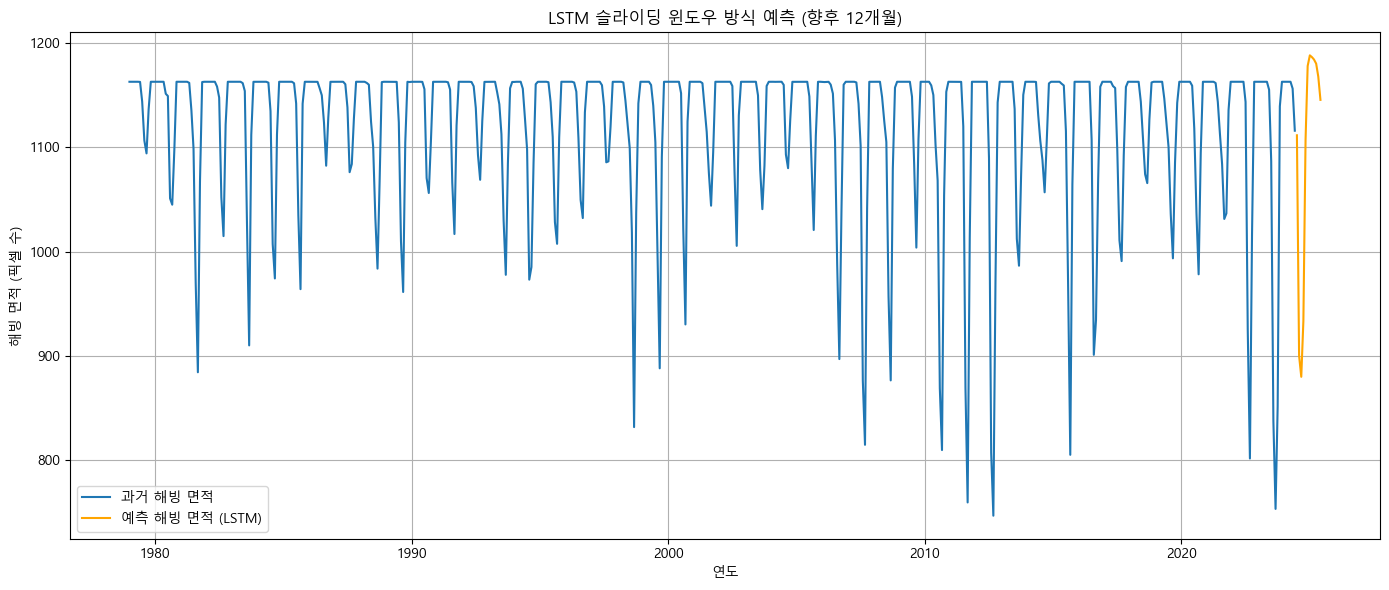

         time  predicted_ice_area
0  2024-07-01         1111.611694
1  2024-08-01          899.835938
2  2024-09-01          879.704956
3  2024-10-01          933.243652
4  2024-11-01         1107.214600
5  2024-12-01         1178.153076
6  2025-01-01         1188.364868
7  2025-02-01         1186.574951
8  2025-03-01         1184.371338
9  2025-04-01         1180.398804
10 2025-05-01         1167.970337
11 2025-06-01         1145.624268


In [20]:
# 9. 시각화
plt.figure(figsize=(14,6))
plt.plot(df.index, df["ice_area"], label="과거 해빙 면적")
plt.plot(future_df["time"], future_df["predicted_ice_area"], label="예측 해빙 면적 (LSTM)", color="orange")
plt.title("LSTM 슬라이딩 윈도우 방식 예측 (향후 12개월)")
plt.xlabel("연도")
plt.ylabel("해빙 면적 (픽셀 수)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. 결과 출력
print(future_df)

# 11. CSV 저장 (선택)
# future_df.to_csv("./data/icedata/predicted_ice_area_lstm_future.csv", index=False)

## 모델 비교 시각화

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ARIMA 모델 재학습 (전체 데이터 기준)
model_arima = SARIMAX(df["ice_area"], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
results_arima = model_arima.fit()

# 미래 12개월 예측
forecast_arima = results_arima.get_forecast(steps=12)
pred_arima = forecast_arima.predicted_mean

# 날짜 생성
future_dates = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# DataFrame 생성
arima_df = pd.DataFrame({
    "time": future_dates,
    "predicted_ice_area": pred_arima.values
})

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


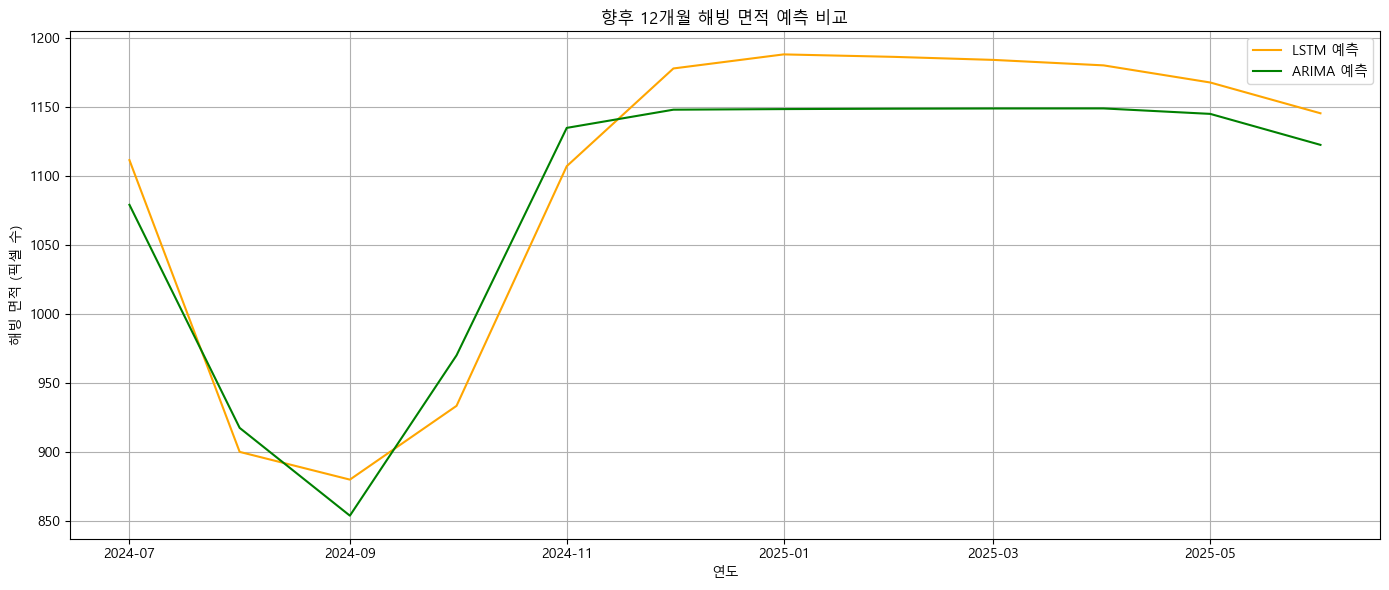

In [27]:
plt.figure(figsize=(14,6))
plt.plot(future_df["time"], future_df["predicted_ice_area"], label="LSTM 예측", color="orange")
plt.plot(arima_df["time"], arima_df["predicted_ice_area"], label="ARIMA 예측", color="green")
plt.title("향후 12개월 해빙 면적 예측 비교")
plt.xlabel("연도")
plt.ylabel("해빙 면적 (픽셀 수)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 성능 지표 계산 함수
def evaluate_model(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = mean_squared_error(true, pred, squared=False)
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

# 성능 지표 입력 (이미 계산한 값 사용)
mae_arima, rmse_arima, mape_arima = 54.03, 88.70, 6.26
mae_lstm, rmse_lstm, mape_lstm = 27.21, 41.41, 2.69

# 성능 개선율 계산
mae_diff = (mae_arima - mae_lstm) / mae_arima * 100
rmse_diff = (rmse_arima - rmse_lstm) / rmse_arima * 100
mape_diff = (mape_arima - mape_lstm) / mape_arima * 100

# 출력
print("성능 지표 비교")
print(f"ARIMA - MAE:  {mae_arima:.2f}, RMSE: {rmse_arima:.2f}, MAPE: {mape_arima:.2f}%")
print(f"LSTM  - MAE:  {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}, MAPE: {mape_lstm:.2f}%\n")

print("LSTM 성능 개선률")
print(f"MAE 개선률:  {mae_diff:.2f}%")
print(f"RMSE 개선률: {rmse_diff:.2f}%")
print(f"MAPE 개선률: {mape_diff:.2f}%")

성능 지표 비교
ARIMA - MAE:  54.03, RMSE: 88.70, MAPE: 6.26%
LSTM  - MAE:  27.21, RMSE: 41.41, MAPE: 2.69%

LSTM 성능 개선률
MAE 개선률:  49.64%
RMSE 개선률: 53.31%
MAPE 개선률: 57.03%
